In [101]:
import pandas as pd
import numpy as np

meta = pd.read_csv("../data/raw/proteomic/all_subtypes.v5.1.tsv",sep = '\t')
meta['rna_wang_cancer_cell_2017'].unique()
tumor_id = meta[meta["sample_type"] == "tumor"]["case"].tolist()
proneural_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Proneural']['case'].tolist()
mesenchymal_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Mesenchymal']['case'].tolist()
classical_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Classical']['case'].tolist()
idh_id = meta[meta['rna_wang_cancer_cell_2017'] == 'IDH mutant']['case'].tolist()
normal_id = meta[meta["sample_type"] == "GTEx normal"]["case"].tolist()
normal_id.pop(2)

'PT-Q2AG'

In [103]:

rna = pd.read_csv(
    "../data/raw/Gene_Expression_RNA/rnaseq_washu_fpkm_uq.v4.0.tsv.gz",
    sep="\t"
)
rna = rna.drop(['gene_id','gene_type','gene_status','havana_gene','full_length','exon_length','exon_num'],axis=1).set_index('gene_name')
print(rna.shape)
rna = np.log2(rna + 1)

pro = pd.read_csv("../data/interim/de_proteome.csv").set_index("gene")
proset = set(pro.index)
rnaset = set(rna.index)

common = list(proset & rnaset)
print(common)
print(len(common))

rna = rna.T
rna = rna[common]
rna = rna.T

(60483, 108)
['LUZP1', 'CCND2', 'PRPSAP2', 'SPC25', 'RHBDD2', 'GPSM2', 'STXBP4', 'TMTC2', 'MRPL48', 'FAM114A2', 'PRRC2B', 'PLP2', 'ABHD17C', 'FLOT2', 'MAX', 'SLC37A4', 'ASNA1', 'FCF1', 'TCEA3', 'CCNT1', 'CBS', 'FPGS', 'GLRX2', 'MOB3C', 'DENND3', 'SLC1A3', 'ANGPTL4', 'WDR5B', 'CNPY2', 'PGAM2', 'PTPRE', 'SPATA33', 'RGS10', 'CD300A', 'WDR33', 'RPN1', 'GPSM3', 'ESYT2', 'SNAPIN', 'WDR35', 'MNAT1', 'SLC44A1', 'PLAU', 'MAF1', 'KCTD10', 'C20orf194', 'TK1', 'RBM8A', 'PUSL1', 'DNM1', 'GRAMD1C', 'LMBRD2', 'BDH2', 'RAD23B', 'SERPINB6', 'RNFT2', 'PAN3', 'WNK1', 'PTPRA', 'LYAR', 'MANEAL', 'PXN', 'SACS', 'SEMA4B', 'BEX4', 'HLA-A', 'POLR3F', 'ST13', 'ALDH7A1', 'CDKN1B', 'PPP5C', 'MYO10', 'LACTB', 'ZNF655', 'TAPT1', 'WIPF2', 'MICAL1', 'ATG4C', 'ARHGAP18', 'PPHLN1', 'MTUS1', 'ETF1', 'MAP1S', 'POLRMT', 'FGFBP2', 'DOCK3', 'E4F1', 'TRAPPC6B', 'PDGFRB', 'TSR1', 'IFIT3', 'UVRAG', 'GAS1', 'SH3TC1', 'HSPB8', 'CKS1B', 'RNF146', 'EFS', 'FAM210B', 'TRAF6', 'IL33', 'RHCE', 'HADHB', 'RHOT2', 'BTBD1', 'CHMP7', 'MRPL

In [104]:
gbm_expr = rna[tumor_id]
proneural_expr = rna[proneural_id]
mesenchymal_expr = rna[mesenchymal_id]
classical_expr = rna[classical_id]
idh_expr = rna[idh_id]
normal_expr = rna[normal_id]
normal_expr

,PT-NPJ7,PT-P44H,PT-QVJO,PT-R55F,PT-RN5K,PT-RU72,PT-UTHO,PT-WVLH,PT-Y8DK
gene_name,,,,,,,,,
LUZP1,18.833631,18.606954,19.011584,18.556121,18.503204,18.709998,18.647405,18.500618,18.958301
CCND2,19.567951,19.645565,19.518877,19.764882,19.428605,19.694727,19.400645,19.950322,19.815314
PRPSAP2,17.201060,17.493302,17.117047,16.915166,16.829249,16.979983,17.328934,17.272932,17.191747
SPC25,13.475072,14.209613,13.469252,13.786686,13.035474,13.550707,13.396301,13.682081,12.865335
RHBDD2,20.087475,20.036860,20.082290,19.593815,19.516389,19.558491,19.586810,20.478356,20.207471
...,...,...,...,...,...,...,...,...,...
CSF2RA,13.748344,15.178256,15.156471,13.992852,13.490472,13.928228,14.616210,14.651075,14.719804
CSF2RA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
MAP3K13,16.906360,16.879729,16.720656,17.073275,16.610807,16.975692,16.804706,17.074123,17.030174


In [ ]:
print(proneural_expr.shape)
print(mesenchymal_expr.shape)
print(classical_expr.shape)

print(proneural_expr.columns[:5])
print(mesenchymal_expr.columns[:5])
print(classical_expr.columns[:5])

(10074, 29)
(10074, 39)
(10074, 25)
Index(['C3L-00104', 'C3L-00677', 'C3L-01146', 'C3L-01149', 'C3L-01157'], dtype='str')
Index(['C3L-00674', 'C3L-01043', 'C3L-01045', 'C3L-01046', 'C3L-01049'], dtype='str')
Index(['C3L-00365', 'C3L-01040', 'C3L-01048', 'C3L-01061', 'C3L-01154'], dtype='str')


In [106]:
def keep_highest_max_duplicate(df):
    return (
        df.assign(_max=df.max(axis=1))
          .sort_values("_max", ascending=False)
          .groupby(level=0)
          .first()
          .drop(columns="_max")
    )

datasets = {
    'gbm': gbm_expr,
    "proneural": proneural_expr,
    "mesenchymal": mesenchymal_expr,
    "classical": classical_expr,
    "idh": idh_expr,
    "normal": normal_expr
}

datasets = {
    name: keep_highest_mean_duplicate(df)
    for name, df in datasets.items()
}

gbm_expr = datasets['gbm']
proneural_expr = datasets["proneural"]
mesenchymal_expr = datasets["mesenchymal"]
classical_expr = datasets["classical"]
idh_expr = datasets["idh"]
normal_expr = datasets["normal"]

# Import diffential analysis module

In [107]:
import diff
import importlib

importlib.reload(diff)

print(dir(diff))

['PCA', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'differential_expression', 'multipletests', 'np', 'pca_plot', 'pd', 'plt', 'ttest_ind', 'volcano_plot']


# Entire dataset

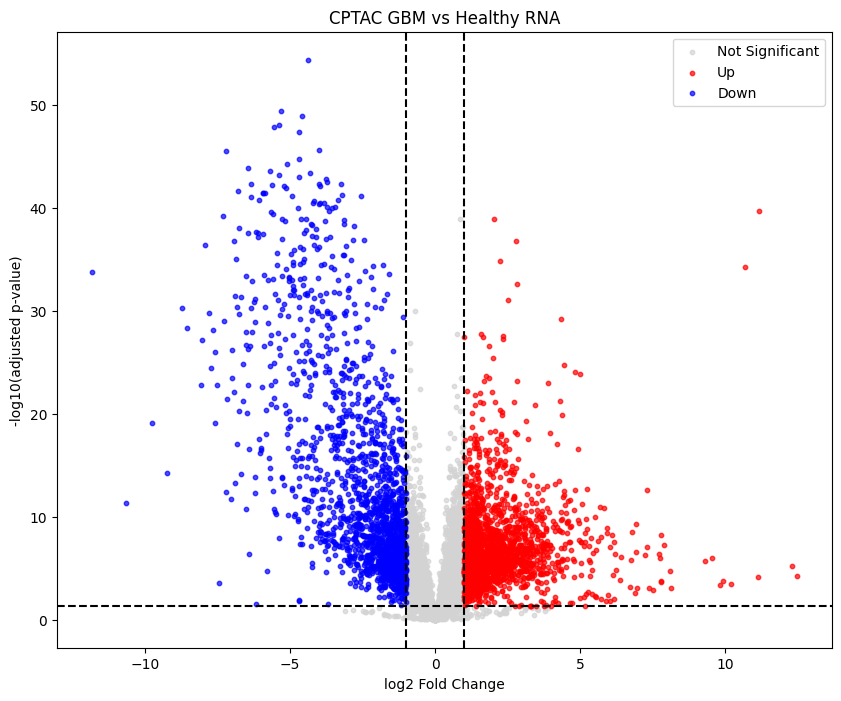

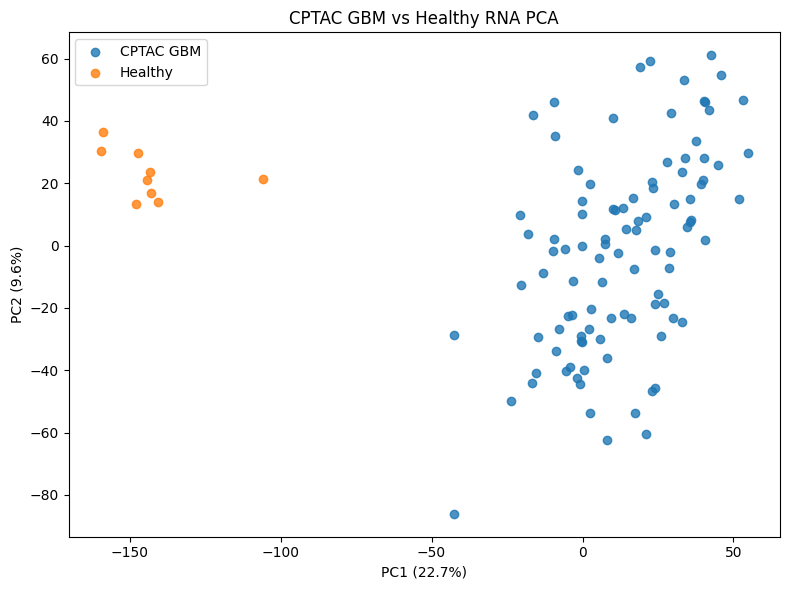

In [108]:
gbm = differential_expression(gbm_expr,normal_expr)
diff.volcano_plot(gbm,'CPTAC GBM vs Healthy RNA')
diff.pca_plot(gbm_expr,normal_expr,'CPTAC GBM','Healthy','CPTAC GBM vs Healthy RNA PCA')
gbm.to_csv('../data/interim/CPTAC_rna_diff.csv')

# Proneural 

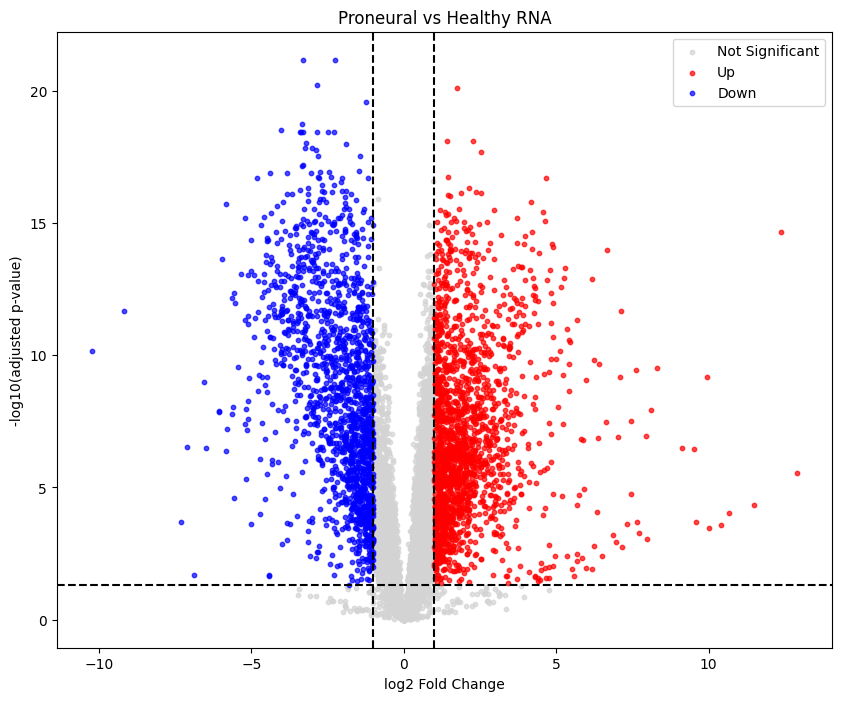

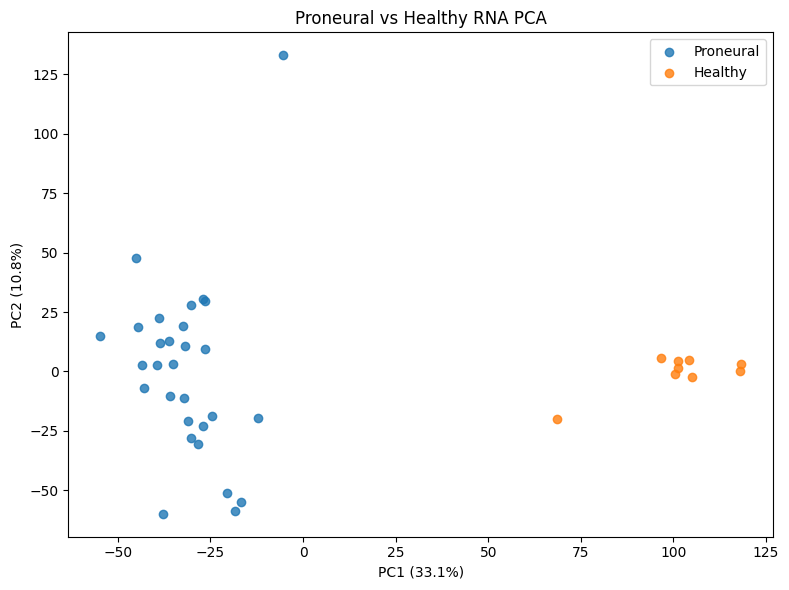

In [109]:
pro = differential_expression(proneural_expr,normal_expr)
volcano_plot(pro,'Proneural vs Healthy RNA')
diff.pca_plot(proneural_expr,normal_expr,'Proneural','Healthy','Proneural vs Healthy RNA PCA')
pro.to_csv('../data/interim/proneural_rna_diff.csv')

# Mesenchymal

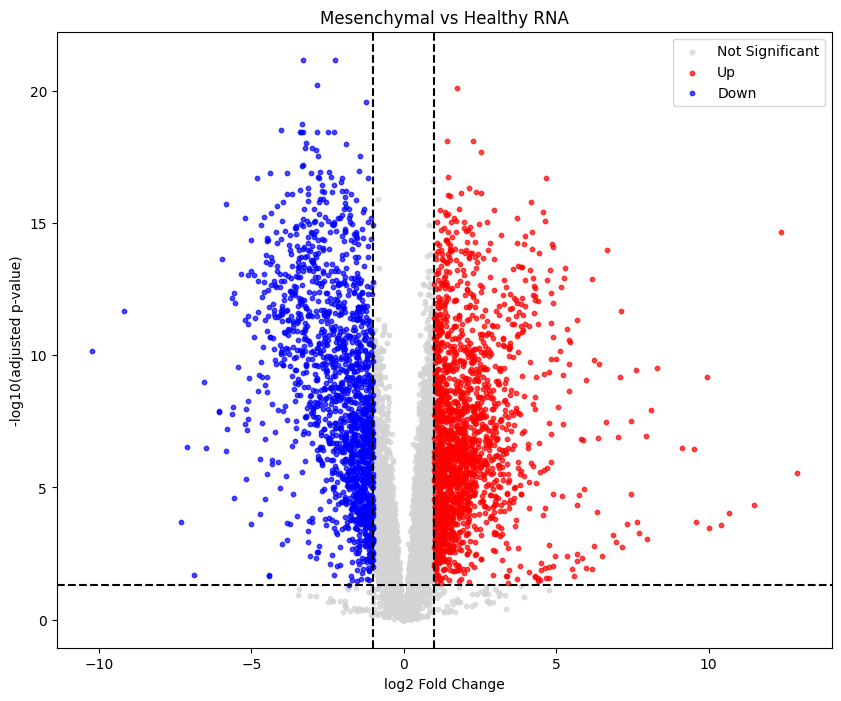

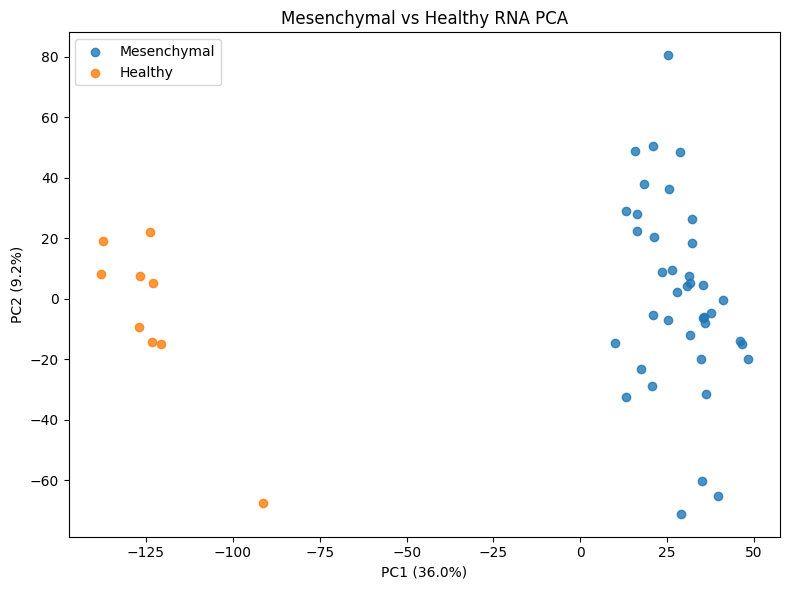

In [110]:
mes = differential_expression(mesenchymal_expr,normal_expr)
volcano_plot(pro,'Mesenchymal vs Healthy RNA')
diff.pca_plot(mesenchymal_expr,normal_expr,'Mesenchymal','Healthy','Mesenchymal vs Healthy RNA PCA')
pro.to_csv('../data/interim/mesenchymal_rna_diff.csv')

# Classical

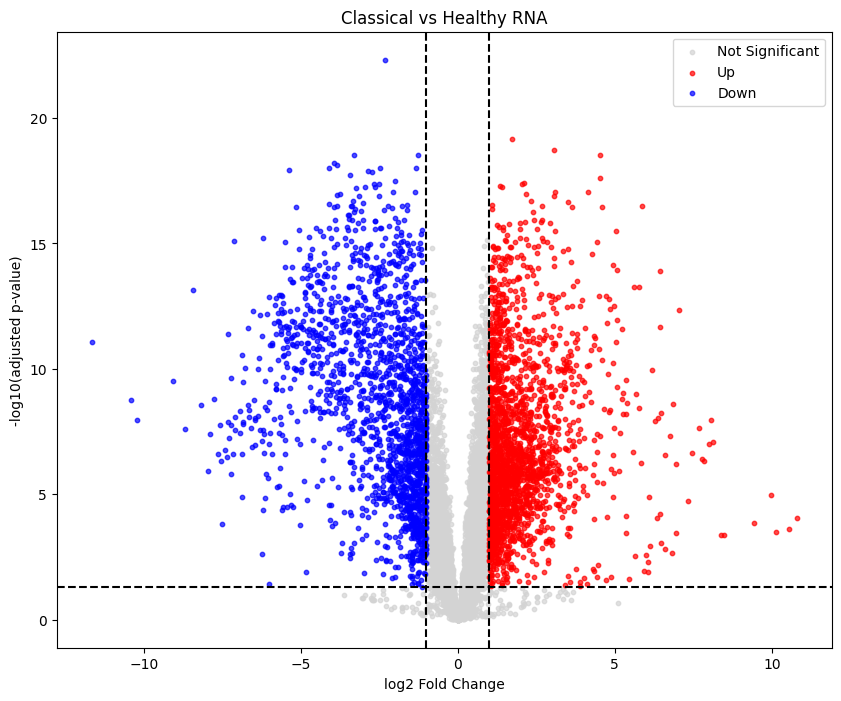

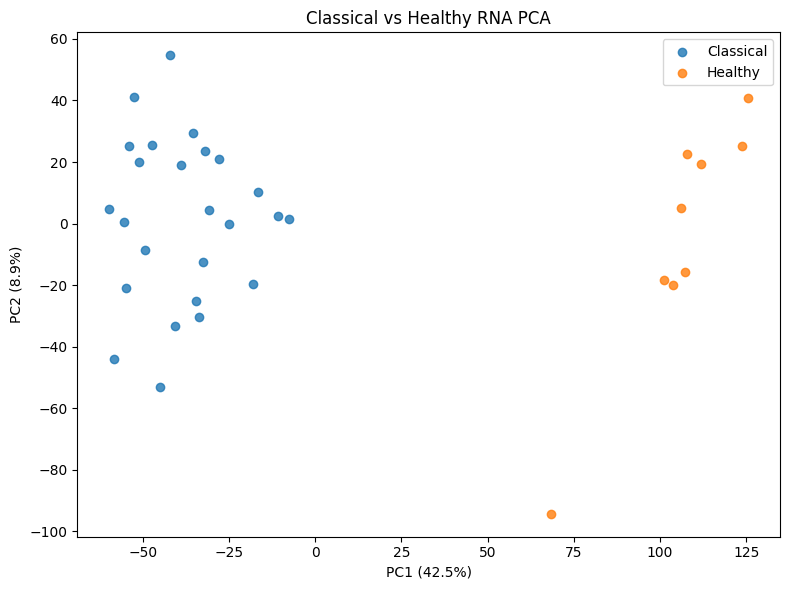

In [111]:
clas = differential_expression(classical_expr,normal_expr)
volcano_plot(clas,'Classical vs Healthy RNA')
diff.pca_plot(classical_expr,normal_expr,'Classical','Healthy','Classical vs Healthy RNA PCA')
pro.to_csv('../data/interim/classical_rna_diff.csv')

# IDH

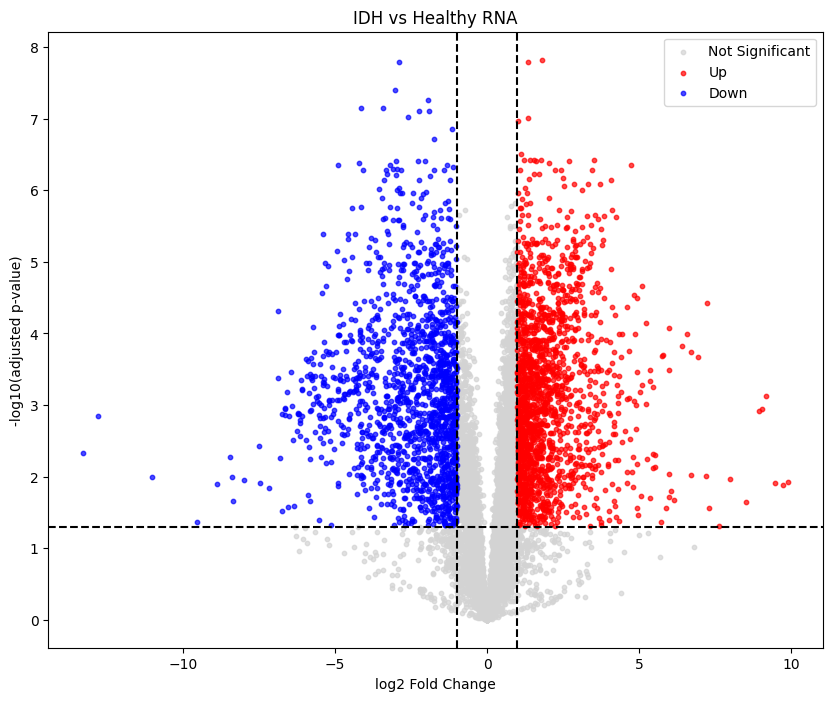

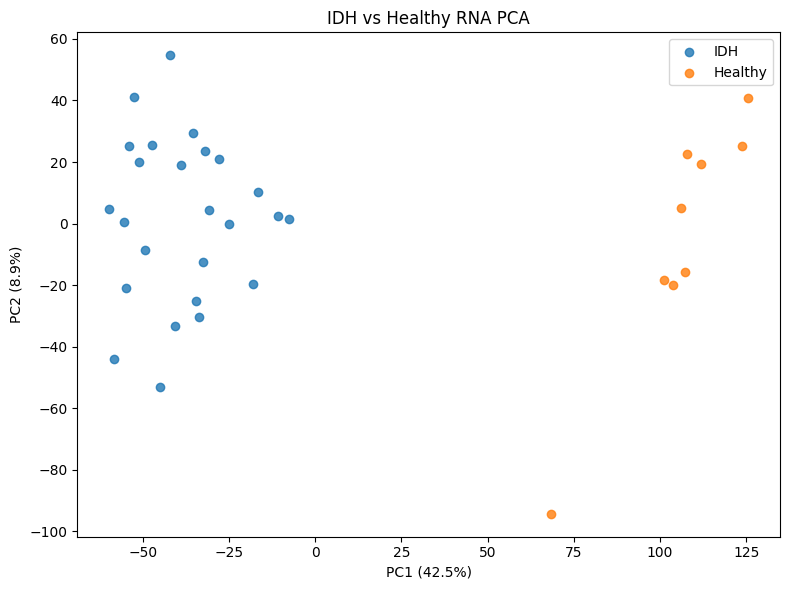

In [112]:
idh = differential_expression(idh_expr,normal_expr)
volcano_plot(idh,'IDH vs Healthy RNA')
diff.pca_plot(classical_expr,normal_expr,'IDH','Healthy','IDH vs Healthy RNA PCA')
pro.to_csv('../data/interim/idh_rna_diff.csv')